# Finetuned pretrained-Model

Similar to the previous approach, this method utilizes a pre-trained model to extract features from the hand images, which are then classified using a fully connected network. However, unlike the previous setup, the final layers of the pre-trained model are unfrozen and fine-tuned to try to achieve higher accuracy.

The model is trained with the same images preprocessed in the same way to ensure consistency between the models.

## Data preparation

In [94]:
import os
import glob
import keras

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input, BatchNormalization, MaxPooling2D

In [95]:
base_dir = ''

train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')
val_dir = os.path.join(base_dir, 'Validation')

one_dir = os.path.join(train_dir, '1')
two_dir = os.path.join(train_dir, '2')
three_dir = os.path.join(train_dir, '3')
four_dir = os.path.join(train_dir, '4')
five_dir = os.path.join(train_dir, '5')

one_imgs = os.listdir(one_dir)
two_imgs = os.listdir(two_dir)
three_imgs = os.listdir(three_dir)
four_imgs = os.listdir(four_dir)
five_imgs = os.listdir(five_dir)

In [96]:
BATCH_SIZE = 24
TARGET_SIZE = 300
EPOCHS = 300

The data is prepared the same way as it was in the previous models.

In [97]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

validation_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [98]:
train_generator = train_datagen.flow_from_directory(train_dir, 
                                                    target_size=(TARGET_SIZE, TARGET_SIZE), 
                                                    batch_size=BATCH_SIZE, 
                                                    shuffle=True,
                                                    class_mode='categorical')

val_generator = validation_test_datagen.flow_from_directory(val_dir,
                                                       target_size=(TARGET_SIZE, TARGET_SIZE), 
                                                       batch_size=BATCH_SIZE, 
                                                       shuffle=True,
                                                       class_mode='categorical')

test_generator = validation_test_datagen.flow_from_directory(test_dir,
                                                  target_size=(TARGET_SIZE, TARGET_SIZE),
                                                  batch_size=BATCH_SIZE,
                                                  shuffle=False,
                                                  class_mode='categorical',
)

Found 210 images belonging to 5 classes.
Found 45 images belonging to 5 classes.
Found 45 images belonging to 5 classes.


## Model

To ensure a reliable comparison between the fine-tuned and unfrozen models, the same architecture as in the previous file was utilized.

In [99]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

The model is also compiled identically to the previous unfrozen model.

In [100]:
model.compile(optimizer = keras.optimizers.Adam(learning_rate=0.00005),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [101]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,210,548 (42.76 MB)

 Trainable params: 427,013 (1.63 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

Since the model architecture was identical to the previous implementation, the training duration remained practically the same. However, due to inherent randomness, the training concluded earlier at epoch 125.

In [102]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=0,
    callbacks=[early_stop],
)

Epoch 133: early stopping
Restoring model weights from the end of the best epoch: 125.


The plots of the fine-tuned model resemble those of the unfrozen model. Surprisingly, the same architecture did not achieve the same level of performance this time.

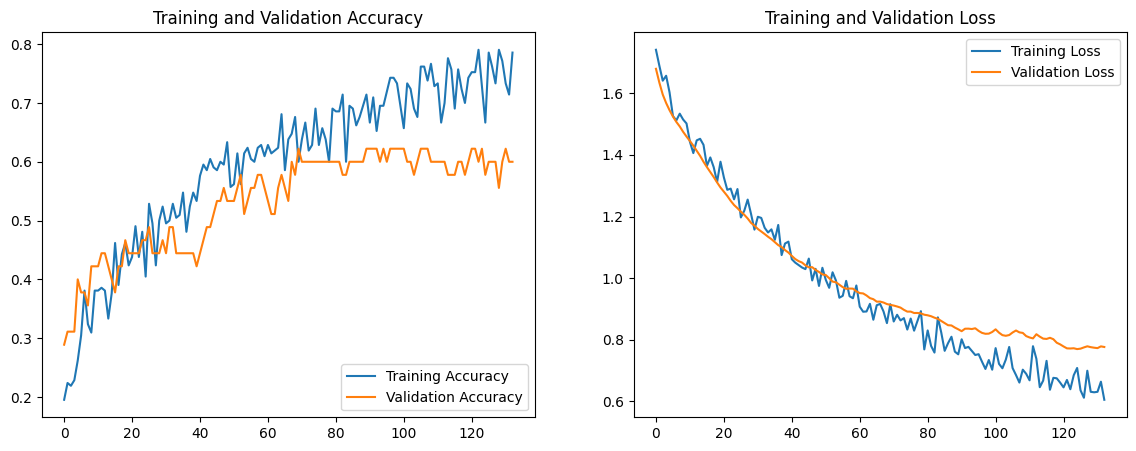

In [103]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

## Fine-tuning

To fine-tune the model, the base model is first made trainable, and after that all layers except the last 30 are frozen to allow the network to adapt its highest-level features to the specific dataset while preserving the generic lower-level features. Additionally, the batch normalization layers are explicitly frozen to prevent distortions in the learned mean and variance that could destabilize the training process.

The model is then recompiled using an Adam optimizer with a low learning rate of 0.00001 to ensure the pre-trained weights are updated slowly.

In [104]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

The model is the trained again with a few more epochs.

In [78]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    verbose=0
)

## Results

The final accuracy of the model is 73%, which is lower than that of the unfrozen model. This difference may be because the baseline model had already achieved a higher accuracy after the first round of training. Although the fine-tuning likely improved the model, this improvement cannot be definitively proven due to the inherent randomness of the training process.

In [80]:
test_loss, test_acc = model.evaluate(val_generator, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

2/2 - 2s - 862ms/step - accuracy: 0.7333 - loss: 0.5689
Test loss: 0.5689246654510498
Test accuracy: 0.7333333492279053


The confusion matrix displays results similar to those of the preceding models. However, in this instance, it produces a single misclassification of more than one finger.

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 749ms/step


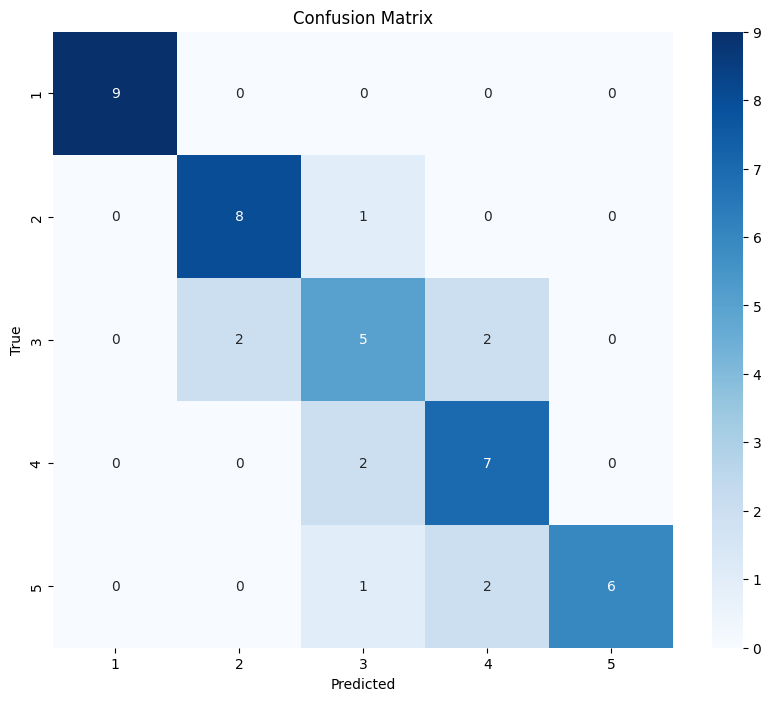

In [81]:
y_true_classes = test_generator.classes

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Below are examples comparing misclassified and correctly classified images, along with the corresponding probabilities assigned by the model.

Total misclassified images: 10 out of 45


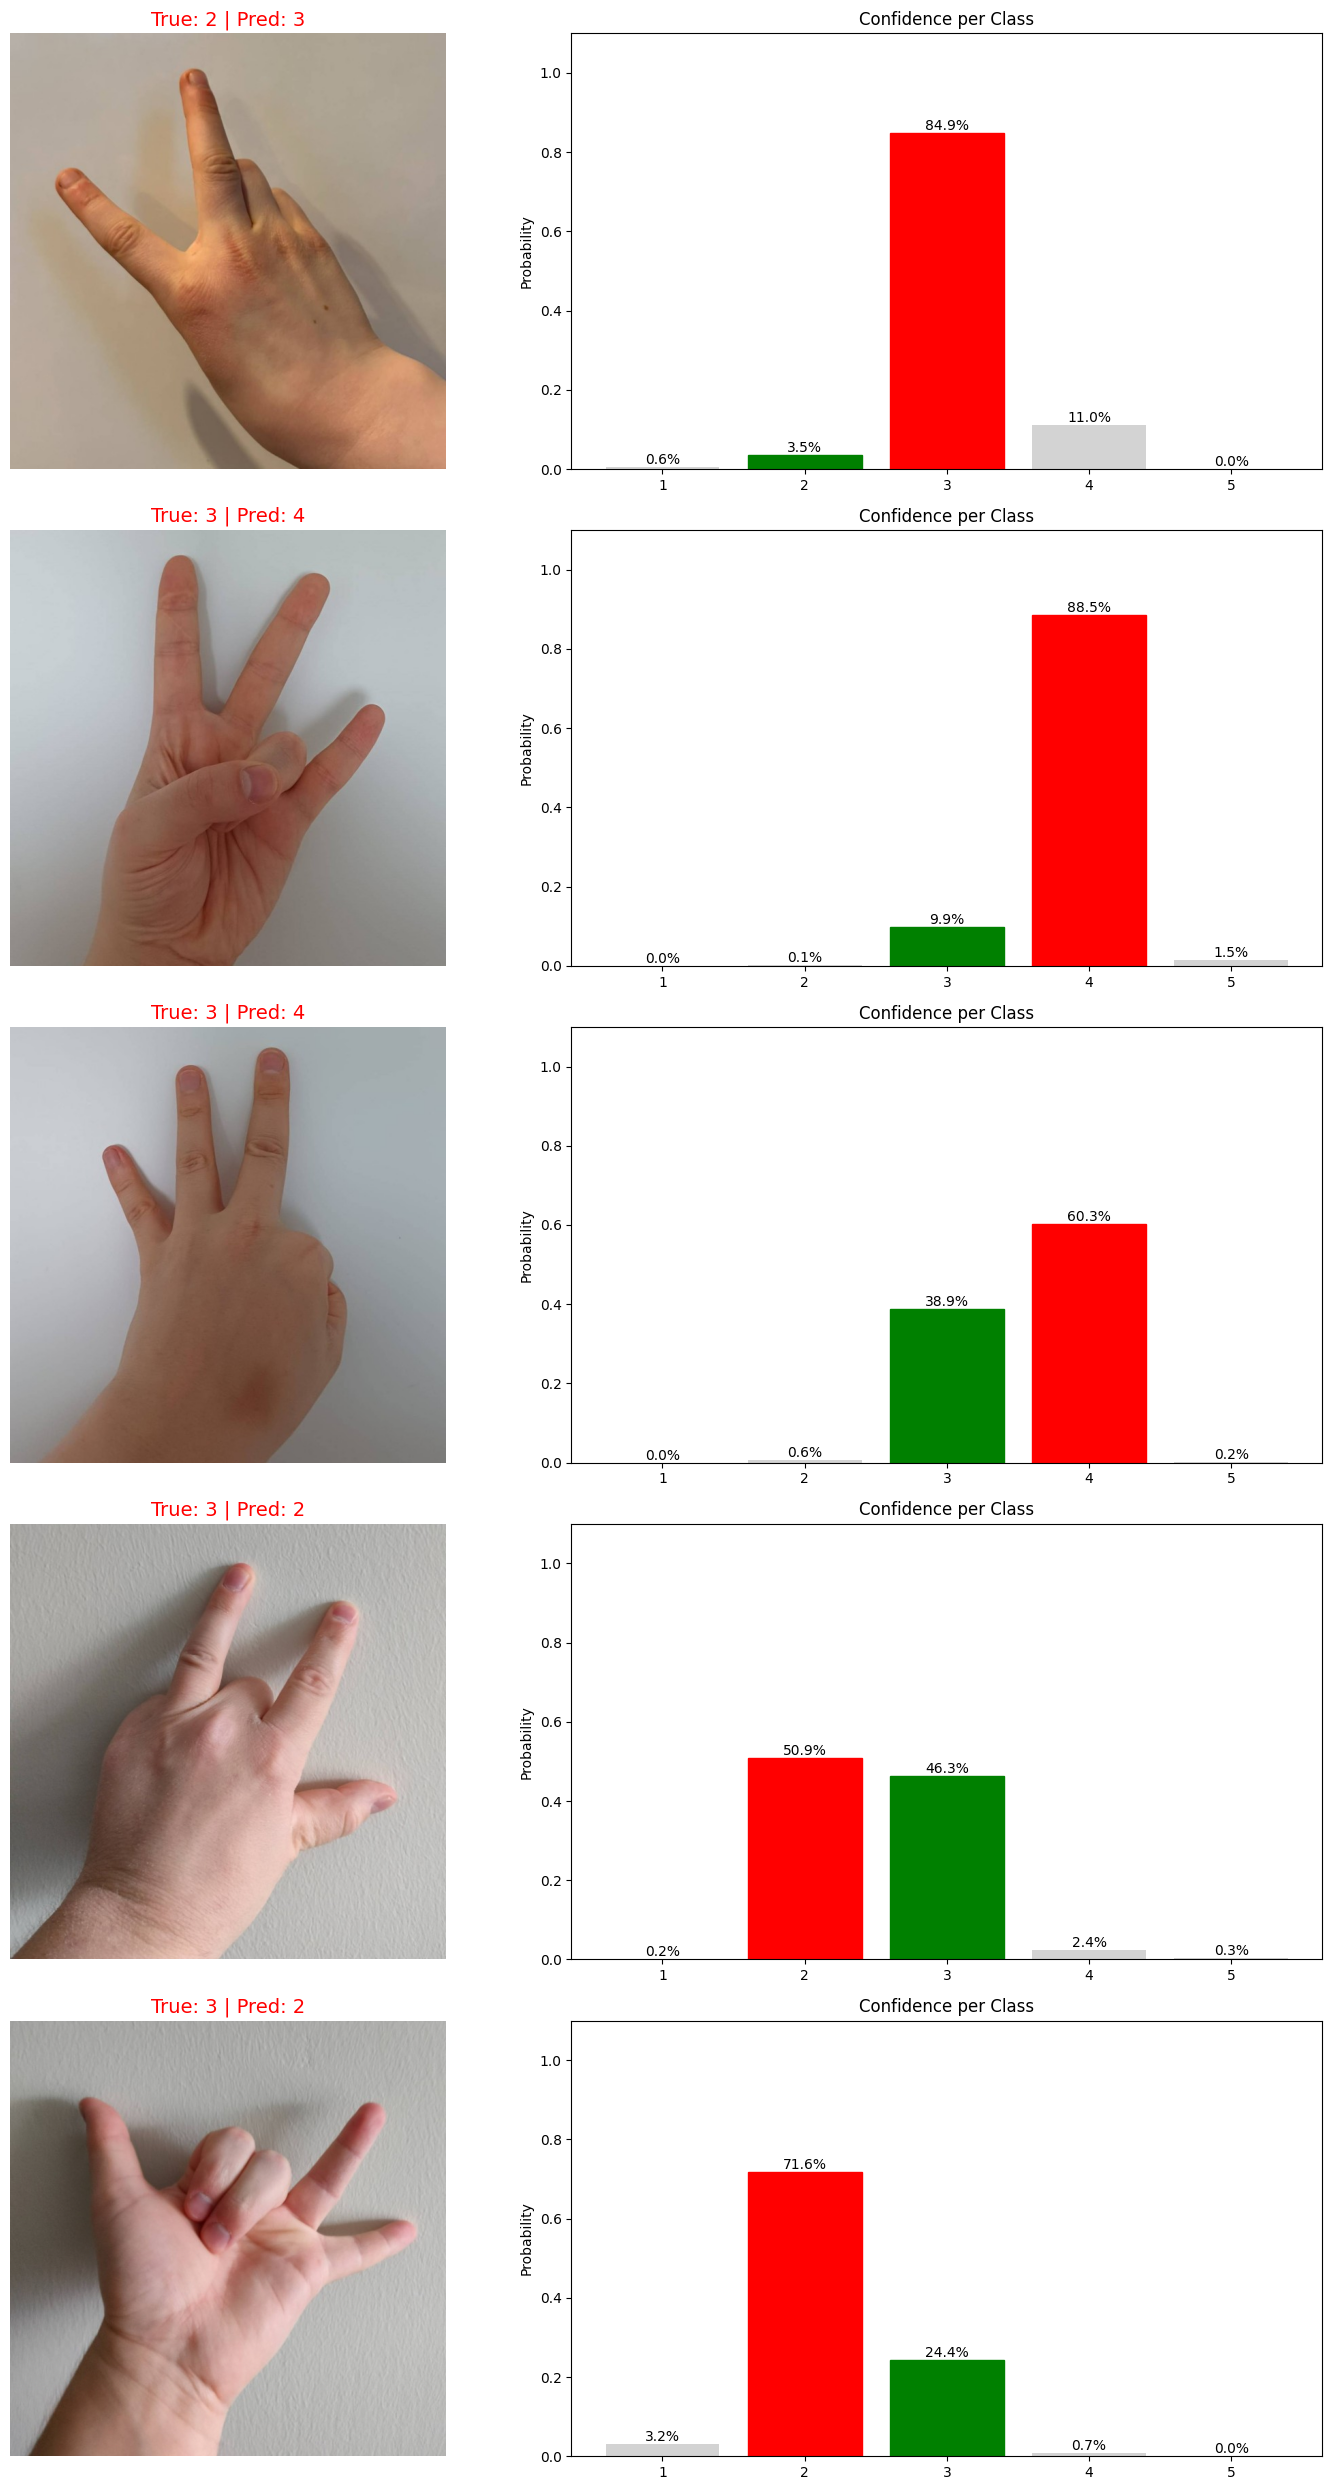

In [108]:
num_to_show = 5 
fig, axes = plt.subplots(num_to_show, 2, figsize=(15, 5 * num_to_show))

num_to_show = min(num_to_show, len(errors))

print(f"Total misclassified images: {len(errors)} out of {len(y_true_classes)}")

for i in range(num_to_show):
    idx = errors[i]
    
    img_path = os.path.join(test_generator.directory, filenames[idx])
    img = plt.imread(img_path)
    
    axes[i, 0].imshow(img)
    true_label = class_names[y_true_classes[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    axes[i, 0].set_title(f"True: {true_label} | Pred: {pred_label}", color='red', fontsize=14)
    axes[i, 0].axis('off')
    
    probabilities = y_pred[idx]
    
    bars = axes[i, 1].bar(class_names, probabilities, color='lightgray')
    
    true_idx = y_true_classes[idx]
    pred_idx = y_pred_classes[idx]
    
    bars[true_idx].set_color('green')
    bars[pred_idx].set_color('red')
    
    for bar in bars:
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height*100:.1f}%', ha='center', va='bottom')

    axes[i, 1].set_ylim(0, 1.1)
    axes[i, 1].set_title("Confidence per Class", fontsize=12)
    axes[i, 1].set_ylabel("Probability")

plt.tight_layout()
plt.show()

Total correctly classified images: 35 out of 45


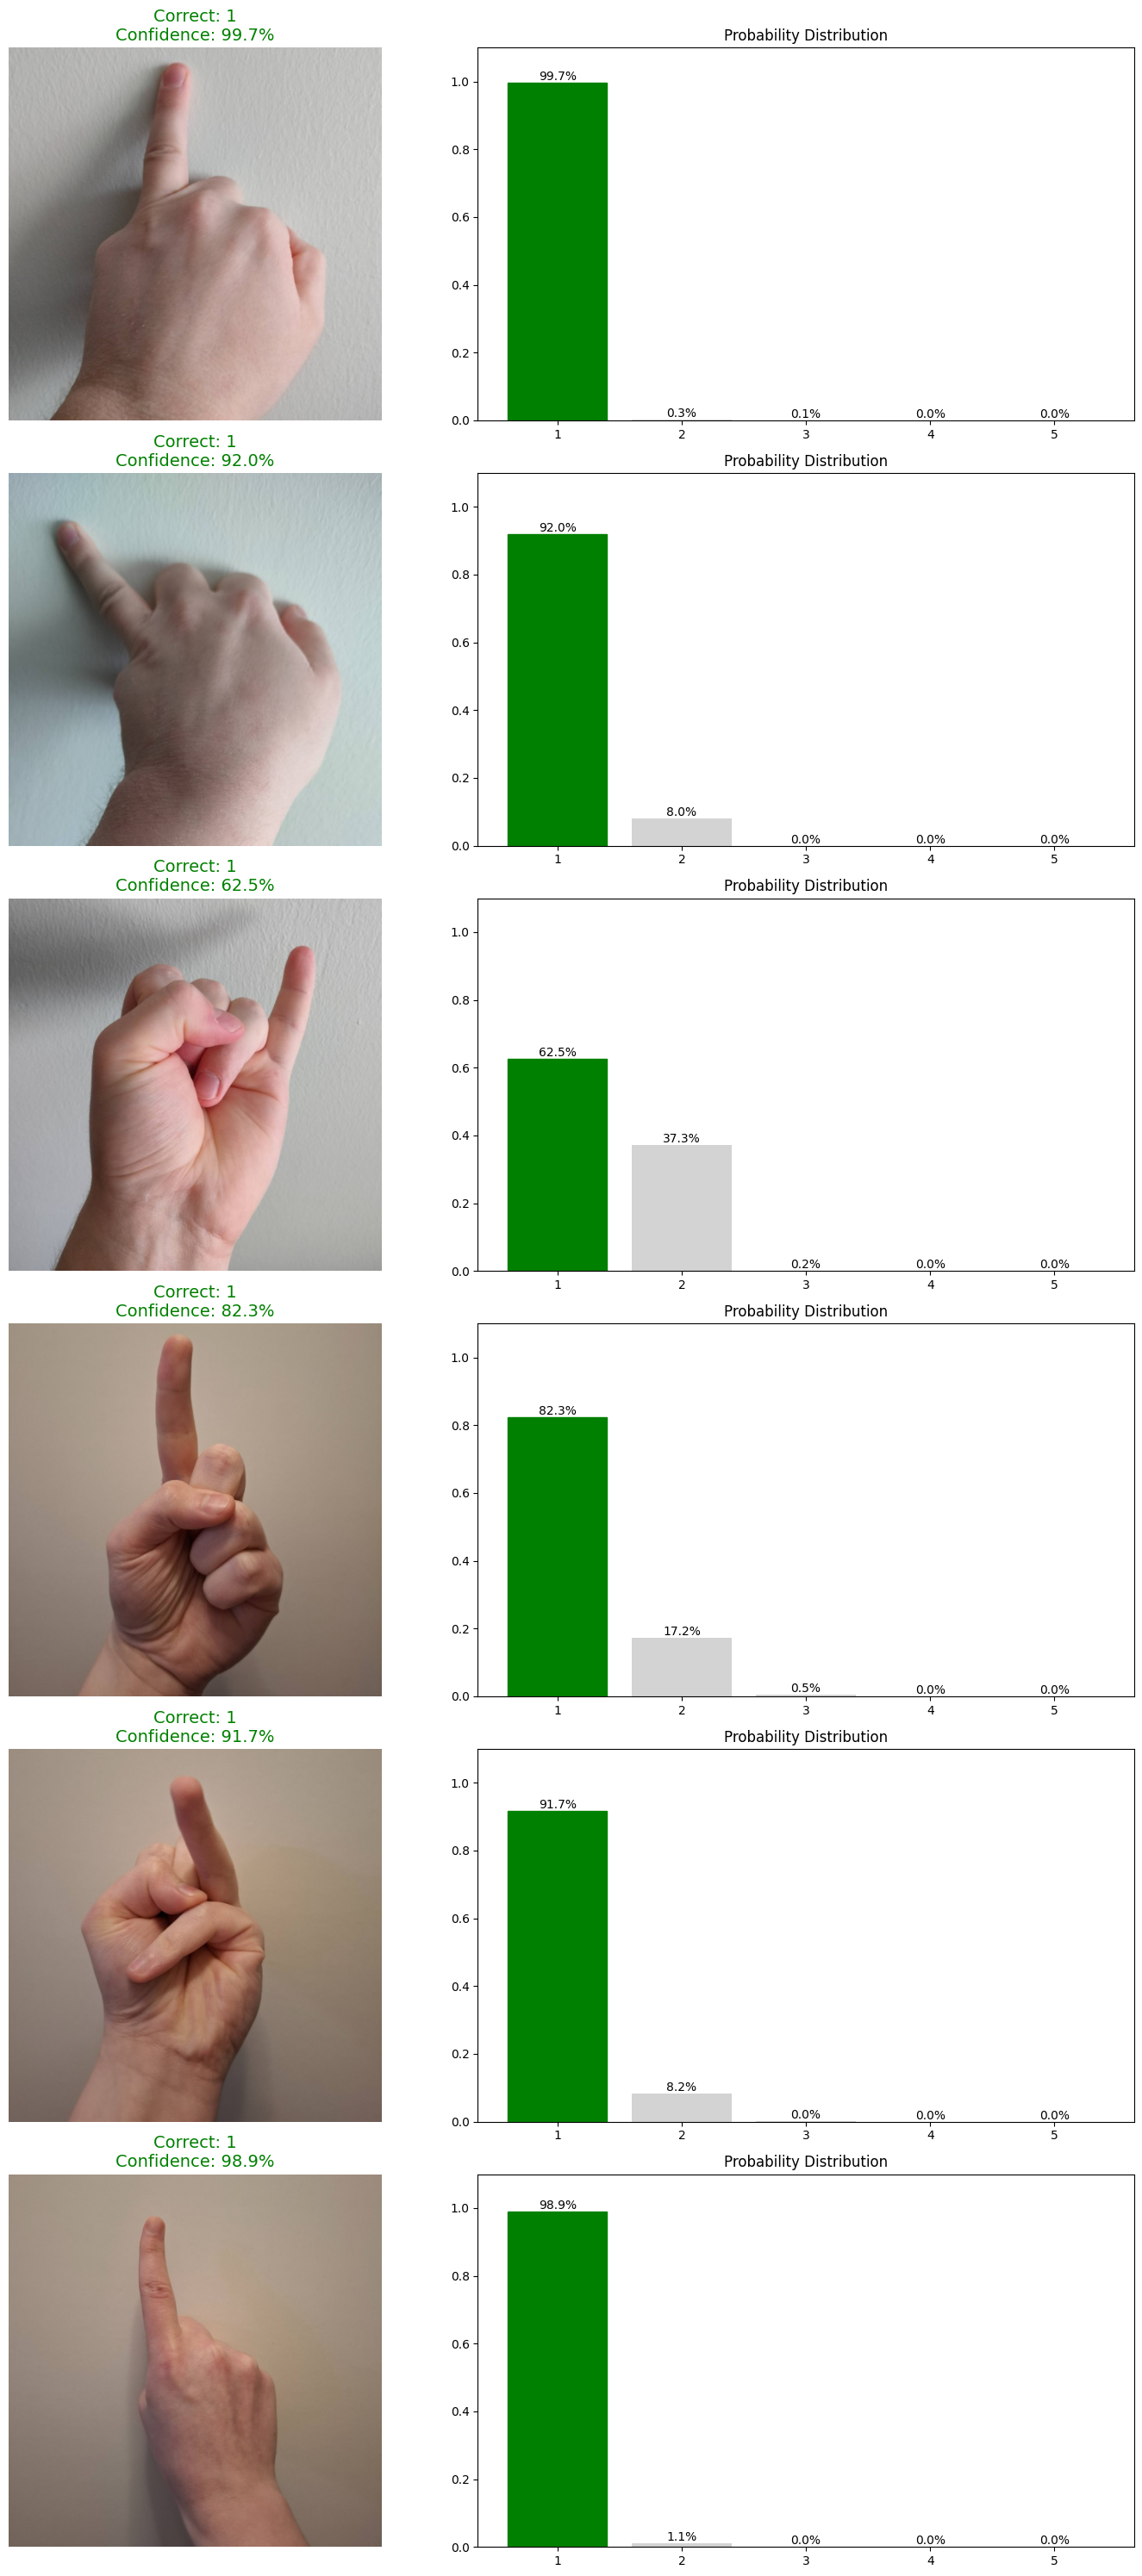

In [107]:
corrects = np.where(y_pred_classes == y_true_classes)[0]
print(f"Total correctly classified images: {len(corrects)} out of {len(y_true_classes)}")

num_to_show = 6 
num_to_show = min(num_to_show, len(corrects))

fig, axes = plt.subplots(num_to_show, 2, figsize=(15, 5 * num_to_show))

for i in range(num_to_show):
    idx = corrects[i]
    
    img_path = os.path.join(test_generator.directory, filenames[idx])
    img = plt.imread(img_path)
    
    axes[i, 0].imshow(img)
    label = class_names[y_true_classes[idx]]
    confidence = y_pred[idx][y_true_classes[idx]] * 100
    
    axes[i, 0].set_title(f"Correct: {label}\nConfidence: {confidence:.1f}%", color='green', fontsize=14)
    axes[i, 0].axis('off')
    
    probabilities = y_pred[idx]
    bars = axes[i, 1].bar(class_names, probabilities, color='lightgray')
    
    correct_idx = y_true_classes[idx]
    bars[correct_idx].set_color('green')
    
    for bar in bars:
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height*100:.1f}%', ha='center', va='bottom')

    axes[i, 1].set_ylim(0, 1.1)
    axes[i, 1].set_title("Probability Distribution", fontsize=12)

plt.tight_layout()
plt.show()

## Discussion

Overall, all the models were sufficient to perform the assigned classification task. Surprisingly, the custom convolutional neural network (CNN) performed the best among the tested models. This outcome may be attributed to the limited amount of data, which starved the more complex models of the information they required for optimal generalization.

The confusion matrices indicate that the models are highly accurate at distinguishing between larger differences in finger counts, struggling only with the most subtle variations. This too is probably caused by the limited image count.

Finally, an analysis of the misclassified images and their corresponding probabilities reveals that the models, especially the custom convolutional neural network, tend to make errors when the fingers do not point in the same direction. This limitation too could likely be addressed by expanding the dataset to include a greater variety of hand shapes and finger orientations. When predicting the finger count correctly, most of the time the models are very sure of their prediction.

All in all these results demonstrate that this type of model is capable of performing the task even with a limited amount of data, particularly when artificially expanding the dataset using data augmentation. In this assignment, the custom convolutional neural network (CNN) performed the best, as its architecture was designed specifically for this task. Additionally, its smaller size made it the fastest to train and the easiest to modify. With more time, resources, and a larger dataset, the models utilizing pre-trained networks as a base would undoubtedly outperform the custom model.